# Credit Risk Analysis — Notebook อธิบายละเอียดทีละขั้นตอน

Notebook นี้ทำการวิเคราะห์ข้อมูลลูกค้าธนาคารชุดเดียวกับ [`analysis.py`](analysis.py) แต่เขียนใหม่ในรูปแบบ Jupyter Notebook พร้อม**คำอธิบายหลักการทำงานของ Data Science แบบละเอียด ทีละขั้นตอน** เป็นภาษาไทยที่เข้าใจง่าย เหมาะสำหรับคนที่อยากรู้ว่า "ทำไมต้องทำแบบนี้" ไม่ใช่แค่ "ทำอะไรบ้าง"

## โจทย์ (Business Questions)

- **Q1** — อะไรทำให้ลูกค้าถูกมองว่า "เสี่ยง" (Credit Risky)?
- **Q2** — ลูกค้าที่ "น่าเชื่อถือ" (Credit Worthy) มีพฤติกรรมแบบไหน?

## ข้อมูลที่ใช้

| ไฟล์ | อธิบาย |
|---|---|
| `data/customer_data.csv` | ข้อมูลลูกค้า 1,125 คน มีคอลัมน์ `label` (1 = เสี่ยงสูง, 0 = น่าเชื่อถือ) และ feature ประชากรศาสตร์ที่เข้ารหัสไว้ (`fea_1`-`fea_11`) |
| `data/payment_data.csv` | ประวัติการชำระเงิน 8,250 แถว (ลูกค้า 1 คนมีได้หลายแถว เพราะถือหลายผลิตภัณฑ์) |

## หลักการทำงานแบบ Data Science (Roadmap)

การวิเคราะห์นี้เดินตามกระบวนการมาตรฐานของ data scientist ทีละขั้น โดยแต่ละขั้นมีเป้าหมายของตัวเอง:

1. **โหลดและรวมข้อมูล (Load & Aggregate)** — ทำให้ข้อมูล 2 ไฟล์ที่โครงสร้างไม่ตรงกัน มารวมกันได้
2. **ทำความสะอาดข้อมูล (Clean)** — จัดการค่าที่หายไปอย่างมีเหตุผล
3. **สำรวจข้อมูล (EDA)** — หาสัญญาณเบื้องต้นด้วยตัวเลขและกราฟ ก่อนสร้างโมเดล
4. **สร้างกราฟ (Visualization)** — แปลงตัวเลขให้เห็นภาพชัดขึ้น
5. **สร้างโมเดล (Modeling)** — ใช้ Machine Learning ยืนยัน/จัดอันดับสิ่งที่เห็นใน EDA
6. **วัดผลโมเดล (Evaluation)** — เช็คว่าเชื่อโมเดลได้แค่ไหน
7. **จัดอันดับปัจจัย (Feature Ranking)** — รวมหลักฐานจากหลายแหล่งเข้าด้วยกัน
8. **สรุปเป็นคำตอบ (Interpretation)** — แปลตัวเลขให้เป็นคำตอบ Q1/Q2 ที่อ่านรู้เรื่อง

ไล่ทำตามลำดับนี้ไปทีละ cell ได้เลยครับ

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, classification_report,
)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_DIR = "data"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## ขั้นที่ 1: โหลดข้อมูล + รวมข้อมูล (Load & Aggregate)

**ปัญหา**: `payment_data.csv` มีได้ **หลายแถวต่อลูกค้า 1 คน** (เพราะลูกค้าอาจถือหลายผลิตภัณฑ์ หรือมีหลายรอบรายงาน) แต่ `customer_data.csv` มี **1 แถวต่อคน** พร้อม label ที่เราต้องการทำนาย

ก่อนจะเอา 2 ไฟล์นี้มารวมกันได้ ต้อง "ยุบ" ประวัติการจ่ายเงินของลูกค้าแต่ละคนให้เหลือแค่คนละ 1 แถวก่อน — ขั้นตอนนี้เรียกว่า **aggregation**

**หลักคิดในการเลือกวิธีสรุปแต่ละคอลัมน์**:

| ประเภทข้อมูล | วิธีสรุป | เหตุผล |
|---|---|---|
| จำนวนครั้งค้างจ่าย/จ่ายปกติ | **sum** (บวกรวม) | อยากรู้ "รวมทั้งหมด" ที่เคยเกิดกับลูกค้าคนนี้ |
| วงเงิน/ยอดคงเหลือ | **mean และ max** | mean = พฤติกรรมทั่วไป, max = จุดที่หนักที่สุดที่เคยเกิดขึ้น (สัญญาณเสี่ยงมักซ่อนอยู่ในค่าสูงสุด) |
| รหัสผลิตภัณฑ์ | **nunique** (นับไม่ซ้ำ) | อยากรู้ว่าถือกี่ผลิตภัณฑ์ ไม่ใช่ผลรวมของรหัส |

โหลดข้อมูลก่อน:

In [2]:
customer = pd.read_csv(f"{DATA_DIR}/customer_data.csv")
payment = pd.read_csv(f"{DATA_DIR}/payment_data.csv")

print("customer_data shape:", customer.shape)
print("payment_data shape :", payment.shape)
print("จำนวนลูกค้าที่มีประวัติจ่ายเงินมากกว่า 1 แถว:",
      (payment.groupby("id").size() > 1).sum())

customer_data shape: (1125, 13)
payment_data shape : (8250, 12)
จำนวนลูกค้าที่มีประวัติจ่ายเงินมากกว่า 1 แถว: 1078


In [3]:
payment_agg = payment.groupby("id").agg(
    ovd_t1_sum=("OVD_t1", "sum"),
    ovd_t2_sum=("OVD_t2", "sum"),
    ovd_t3_sum=("OVD_t3", "sum"),
    ovd_days_sum=("OVD_sum", "sum"),
    pay_normal_sum=("pay_normal", "sum"),
    n_products=("prod_code", "nunique"),
    n_payment_records=("id", "size"),
    prod_limit_mean=("prod_limit", "mean"),
    prod_limit_max=("prod_limit", "max"),
    new_balance_mean=("new_balance", "mean"),
    new_balance_max=("new_balance", "max"),
    highest_balance_mean=("highest_balance", "mean"),
    highest_balance_max=("highest_balance", "max"),
).reset_index()

# สร้างตัวชี้วัดพฤติกรรมใหม่: สัดส่วนการค้างจ่าย
# เหตุผล: "จำนวนครั้งค้างจ่าย" ดิบๆ อย่างเดียวทำให้เข้าใจผิดได้ เช่น
# ค้างจ่าย 5 ครั้งจาก 100 ครั้ง (น้อยมาก) กับค้างจ่าย 5 ครั้งจาก 6 ครั้ง (บ่อยมาก)
# มีจำนวนเท่ากันแต่พฤติกรรมต่างกันสุดขั้ว การใช้ "สัดส่วน" แก้ปัญหานี้
ovd_total = payment_agg["ovd_t1_sum"] + payment_agg["ovd_t2_sum"] + payment_agg["ovd_t3_sum"]
payment_agg["overdue_ratio"] = ovd_total / (ovd_total + payment_agg["pay_normal_sum"]).replace(0, np.nan)

print("payment_agg (1 แถวต่อลูกค้า 1 คน) shape:", payment_agg.shape)
payment_agg.head()

payment_agg (1 แถวต่อลูกค้า 1 คน) shape: (1125, 15)


,id,ovd_t1_sum,ovd_t2_sum,ovd_t3_sum,ovd_days_sum,pay_normal_sum,n_products,n_payment_records,prod_limit_mean,prod_limit_max,new_balance_mean,new_balance_max,highest_balance_mean,highest_balance_max,overdue_ratio
0,54982353,3,2,38,32078,229,3,18,259600.0,660000.0,42033.133333,326684.4,246583.714286,775030.0,0.158088
1,54982356,0,0,0,0,117,4,7,330000.0,330000.0,2277.771429,15938.4,196649.285714,600500.0,0.000000
2,54982387,3,0,0,12,246,3,11,109450.0,330000.0,117455.127273,917833.2,238270.000000,1200500.0,0.012048
3,54982463,0,0,0,0,34,2,2,NaN,NaN,39890.400000,79780.8,78500.000000,100500.0,0.000000
4,54982530,0,0,0,0,56,1,4,94600.0,134200.0,1261.200000,4371.6,12787.750000,24117.0,0.000000


**จุดประสงค์ของตารางนี้**: เป็นตัวอย่าง 5 แถวแรกของข้อมูลหลังรวม (aggregate) แล้ว ใช้เช็คว่าการรวมข้อมูลทำงานถูกต้องหรือไม่ — แต่ละแถวควรมี `id` ไม่ซ้ำกัน (1 แถวต่อลูกค้า 1 คน) และตัวเลขในแต่ละคอลัมน์ควรสมเหตุสมผล (เช่น `overdue_ratio` ควรอยู่ระหว่าง 0-1 เสมอ)

## ขั้นที่ 2: รวมเข้ากับ customer_data + ทำความสะอาดข้อมูล (Merge & Clean)

ใช้ `merge(..., how="left")` เพื่อเก็บลูกค้าทุกคนจาก `customer_data` ไว้ครบ (ไม่ทิ้งใคร) โดยยึด `customer_data` เป็นตารางหลัก เพราะเป็นตารางที่มี label อยู่

**หลักคิดในการเติมค่าที่หายไป (missing values)**: ไม่ใช้วิธีเดียวกันหมด แต่เลือกตามความหมายของคอลัมน์นั้น

- ค่าที่เป็น **"จำนวนครั้ง/นับ"** (เช่น จำนวนครั้งค้างจ่าย) → เติมด้วย **0** เพราะไม่มีข้อมูล = ไม่เคยเกิดเหตุการณ์นั้นกับลูกค้าคนนี้เลย
- ค่าที่เป็น **"จำนวนเงิน"** (วงเงิน, ยอดคงเหลือ) → เติมด้วย **ค่ากลาง (median)** เพราะไม่อยากบอกว่าวงเงิน = 0 (จะบิดเบือนความจริง) และ median ทนทานต่อค่าผิดปกติสุดโต่ง (outlier) ได้ดีกว่าค่าเฉลี่ย (mean)

In [4]:
df = customer.merge(payment_agg, on="id", how="left")
print("Merged shape:", df.shape)

missing = df.isna().sum()
missing = missing[missing > 0]
print("\nคอลัมน์ที่มีค่าหายไป:\n", missing)

Merged shape: (1125, 27)

คอลัมน์ที่มีค่าหายไป:
 fea_2              149
prod_limit_mean    180
prod_limit_max     180
dtype: int64


In [5]:
# ค่าที่เป็นจำนวนครั้ง/นับ -> เติม 0
count_like_cols = [
    "ovd_t1_sum", "ovd_t2_sum", "ovd_t3_sum", "ovd_days_sum",
    "pay_normal_sum", "n_products", "n_payment_records",
]
df[count_like_cols] = df[count_like_cols].fillna(0)

# ค่าที่เป็นจำนวนเงิน -> เติม median
balance_like_cols = [
    "prod_limit_mean", "prod_limit_max",
    "new_balance_mean", "new_balance_max",
    "highest_balance_mean", "highest_balance_max",
]
for col in balance_like_cols:
    df[col] = df[col].fillna(df[col].median())

# overdue_ratio เป็น NaN เมื่อลูกค้าไม่มีประวัติจ่ายเงินเลย (0/0) -> ถือว่า 0
df["overdue_ratio"] = df["overdue_ratio"].fillna(0)

# fea_2 เป็น feature ประชากรศาสตร์จาก customer_data เอง -> เติมด้วย median เช่นกัน
df["fea_2"] = df["fea_2"].fillna(df["fea_2"].median())

print("ค่าที่หายไปที่เหลืออยู่หลังทำความสะอาด:", df.isna().sum().sum())
print("\nสัดส่วนกลุ่มลูกค้า (class balance):\n", df["label"].value_counts(normalize=True))

ค่าที่หายไปที่เหลืออยู่หลังทำความสะอาด: 0

สัดส่วนกลุ่มลูกค้า (class balance):
 label
0    0.8
1    0.2
Name: proportion, dtype: float64


**สิ่งที่พบ**: ข้อมูล **ไม่สมดุล (imbalanced)** — มีลูกค้ากลุ่มไม่เสี่ยง (label=0) ถึง 80% เทียบกับกลุ่มเสี่ยง (label=1) แค่ 20% เรื่องนี้สำคัญมากและต้องจำไว้ตอนสร้างโมเดล ไม่งั้นโมเดลจะ "ขี้เกียจ" เรียนรู้กลุ่มเสี่ยง เพราะแค่ทายว่า "ไม่เสี่ยง" ตลอดก็ได้ accuracy ถึง 80% แล้ว

## ขั้นที่ 3: สำรวจข้อมูล (EDA) — เปรียบเทียบกลุ่มเสี่ยง vs ไม่เสี่ยง

นี่คือวิธีที่ตรงไปตรงมาที่สุดในการเริ่มหาคำตอบ Q1/Q2: **เทียบค่าเฉลี่ยของแต่ละ feature ระหว่าง 2 กลุ่ม** ถ้าค่าเฉลี่ยต่างกันเยอะ แปลว่า feature นั้นน่าจะเป็นสัญญาณสำคัญ

ใช้ `groupby("label").mean()` แล้วคำนวณ **% ส่วนต่าง (pct_diff)** แทนตัวเลขดิบ เพราะ feature แต่ละตัวมีหน่วย/สเกลต่างกันมาก (บางตัวหลักแสน บางตัวหลักหน่วย) การใช้ % ทำให้เทียบ "ขนาดผลกระทบ" ข้าม feature ได้อย่างยุติธรรม

ส่วน `fea_1, fea_3, fea_5, fea_6, fea_7, fea_9` เป็น feature ประเภท **categorical** (รหัสหมวดหมู่ ไม่มีลำดับความหมาย) จึงแยกไปเทียบด้วยวิธี crosstab (ดูสัดส่วน) แทนการเทียบค่าเฉลี่ย

In [6]:
categorical_cols = ["fea_1", "fea_3", "fea_5", "fea_6", "fea_7", "fea_9"]
id_label_cols = ["id", "label"]
numeric_cols = [c for c in df.columns if c not in categorical_cols + id_label_cols]

group_means = df.groupby("label")[numeric_cols].mean().T
group_means.columns = ["worthy_mean (label=0)", "risky_mean (label=1)"]
group_means["diff (risky - worthy)"] = (
    group_means["risky_mean (label=1)"] - group_means["worthy_mean (label=0)"]
)
group_means["pct_diff_%"] = (
    group_means["diff (risky - worthy)"] / group_means["worthy_mean (label=0)"].replace(0, np.nan) * 100
)
group_means = group_means.sort_values("pct_diff_%", key=abs, ascending=False)

group_means.round(2)

,worthy_mean (label=0),risky_mean (label=1),diff (risky - worthy),pct_diff_%
new_balance_max,402363.25,1321926.41,919563.16,228.54
highest_balance_max,469921.60,1444798.94,974877.33,207.46
highest_balance_mean,124362.20,341386.70,217024.50,174.51
new_balance_mean,71114.69,170593.93,99479.23,139.89
overdue_ratio,0.03,0.06,0.03,107.38
ovd_days_sum,1151.90,2274.05,1122.15,97.42
ovd_t2_sum,0.79,1.51,0.72,91.82
ovd_t3_sum,2.37,4.04,1.67,70.41
ovd_t1_sum,1.69,2.38,0.69,40.79
pay_normal_sum,113.32,79.37,-33.95,-29.96


**จุดประสงค์ของตารางนี้**: เป็นตารางหลักที่ใช้ตอบ Q1/Q2 ในเชิงตัวเลขเป็นครั้งแรก เรียงจาก feature ที่ค่าเฉลี่ยต่างกันมากที่สุดระหว่าง 2 กลุ่มไปหาน้อยที่สุด (ดูคอลัมน์ `pct_diff_%`) — ยิ่งอยู่บนสุดยิ่งเป็น 'ตัวชี้วัดความเสี่ยง' ที่ต่างกันชัดเจนที่สุด ใช้เป็นเบาะแสตั้งต้นก่อนจะไปยืนยันด้วยโมเดลในขั้นถัดไป

In [7]:
for col in categorical_cols:
    ct = pd.crosstab(df[col], df["label"], normalize="columns") * 100
    ct.columns = ["worthy_% (label=0)", "risky_% (label=1)"]
    print(f"\n-- {col} --")
    print(ct.round(1))


-- fea_1 --
       worthy_% (label=0)  risky_% (label=1)
fea_1                                       
1                     0.7                0.4
2                     0.1                0.4
4                    34.8               28.4
5                    23.1               23.6
6                     0.2                0.0
7                    41.1               47.1

-- fea_3 --
       worthy_% (label=0)  risky_% (label=1)
fea_3                                       
1                    29.1               20.9
2                    10.9               15.1
3                    60.0               64.0

-- fea_5 --
       worthy_% (label=0)  risky_% (label=1)
fea_5                                       
1                     7.3                6.2
2                    92.7               93.8

-- fea_6 --
       worthy_% (label=0)  risky_% (label=1)
fea_6                                       
3                     0.1                0.4
4                     0.4                0.0
5  

**จุดประสงค์ของตารางนี้**: เช็คว่าสัดส่วนของแต่ละหมวดหมู่ใน categorical feature (เช่น `fea_6`) ต่างกันระหว่างกลุ่มเสี่ยง/ไม่เสี่ยงหรือไม่ ถ้าตัวเลข % ระหว่าง 2 คอลัมน์ ใกล้เคียงกันมาก แปลว่า feature นั้นแทบไม่ช่วยแยกแยะความเสี่ยงเลย

**สรุปขั้นนี้**: ทั้งตาราง `group_means` และ `crosstab` ด้านบนชี้ไปทางเดียวกัน — feature ด้านพฤติกรรมการเงิน (ยอดหนี้ ค้างจ่าย จ่ายปกติ) ต่างกันระหว่าง 2 กลุ่มมากกว่า feature ประชากรศาสตร์อย่างชัดเจน นี่คือเบาะแสตั้งต้นที่จะเอาไปยืนยันด้วยโมเดลในขั้นถัดไป

## ขั้นที่ 4: สร้างกราฟ EDA (Visualization)

ตัวเลขในตารางอ่านยากเมื่อมีหลาย feature พร้อมกัน กราฟช่วยให้เห็น pattern ได้เร็วขึ้น จะสร้าง 3 กราฟ:

1. **Class balance** — ยืนยันภาพสัดส่วน 80/20 ที่เจอไปแล้ว
2. **Boxplot** ของ 8 feature ที่ต่างกันมากที่สุด — เห็น "การกระจายตัว" ของข้อมูลจริง ไม่ใช่แค่ค่าเฉลี่ย
3. **Correlation bar chart** — จัดอันดับทุก feature พร้อมทิศทาง (บวก = สัมพันธ์กับความเสี่ยง, ลบ = สัมพันธ์กับความน่าเชื่อถือ) ในภาพเดียว

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/539376113.py:6: UserWarning: Glyp

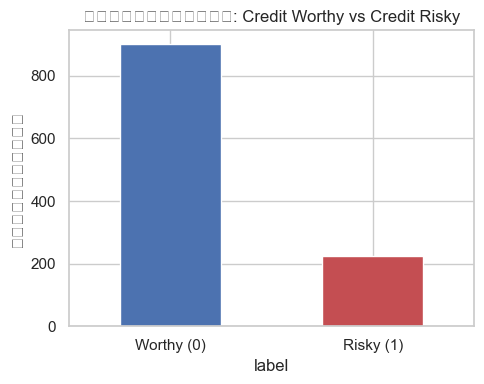

In [8]:
plt.figure(figsize=(5, 4))
df["label"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.xticks([0, 1], ["Worthy (0)", "Risky (1)"], rotation=0)
plt.ylabel("จำนวนลูกค้า")
plt.title("สัดส่วนกลุ่ม: Credit Worthy vs Credit Risky")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_class_balance.png", dpi=150)
plt.show()

**จุดประสงค์ของกราฟนี้**: ยืนยันด้วยภาพว่าข้อมูลไม่สมดุล (imbalanced) มากแค่ไหน — แท่ง 'Worthy' ควรสูงกว่า 'Risky' อย่างชัดเจน (80% vs 20%) ข้อเท็จจริงนี้สำคัญมาก เพราะเป็นเหตุผลที่ต้องใช้ `class_weight="balanced"` ตอนสร้างโมเดลในขั้นถัดไป

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=col, ax=ax, palette=["#4C72B0", "#C44E52"], showfliers=False)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Worthy", "Risky"])
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=col, ax=ax, palette=["#4C72B0", "#C44E52"], showfliers=False)
/var/folders/wh/j9l7p17d07s26z0

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Worthy", "Risky"])
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y=col, ax=ax, palette=["#4C72B0", "#C44E52"], showfliers=False)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Worthy", "Risky"])
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is d

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:9: UserWarning: Glyph

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:10: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}/02_top_features_boxplots.png", dpi=150)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:10: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}/02_top_features_boxplots.png", dpi=150)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:10: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}/02_top_features_boxplots.png", dpi=150)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:10: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  plt.savefig(f"{OUTPUT_DIR}/02_top_features_boxplots.png", dpi=150)
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/513619742.py:10: Use

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/an

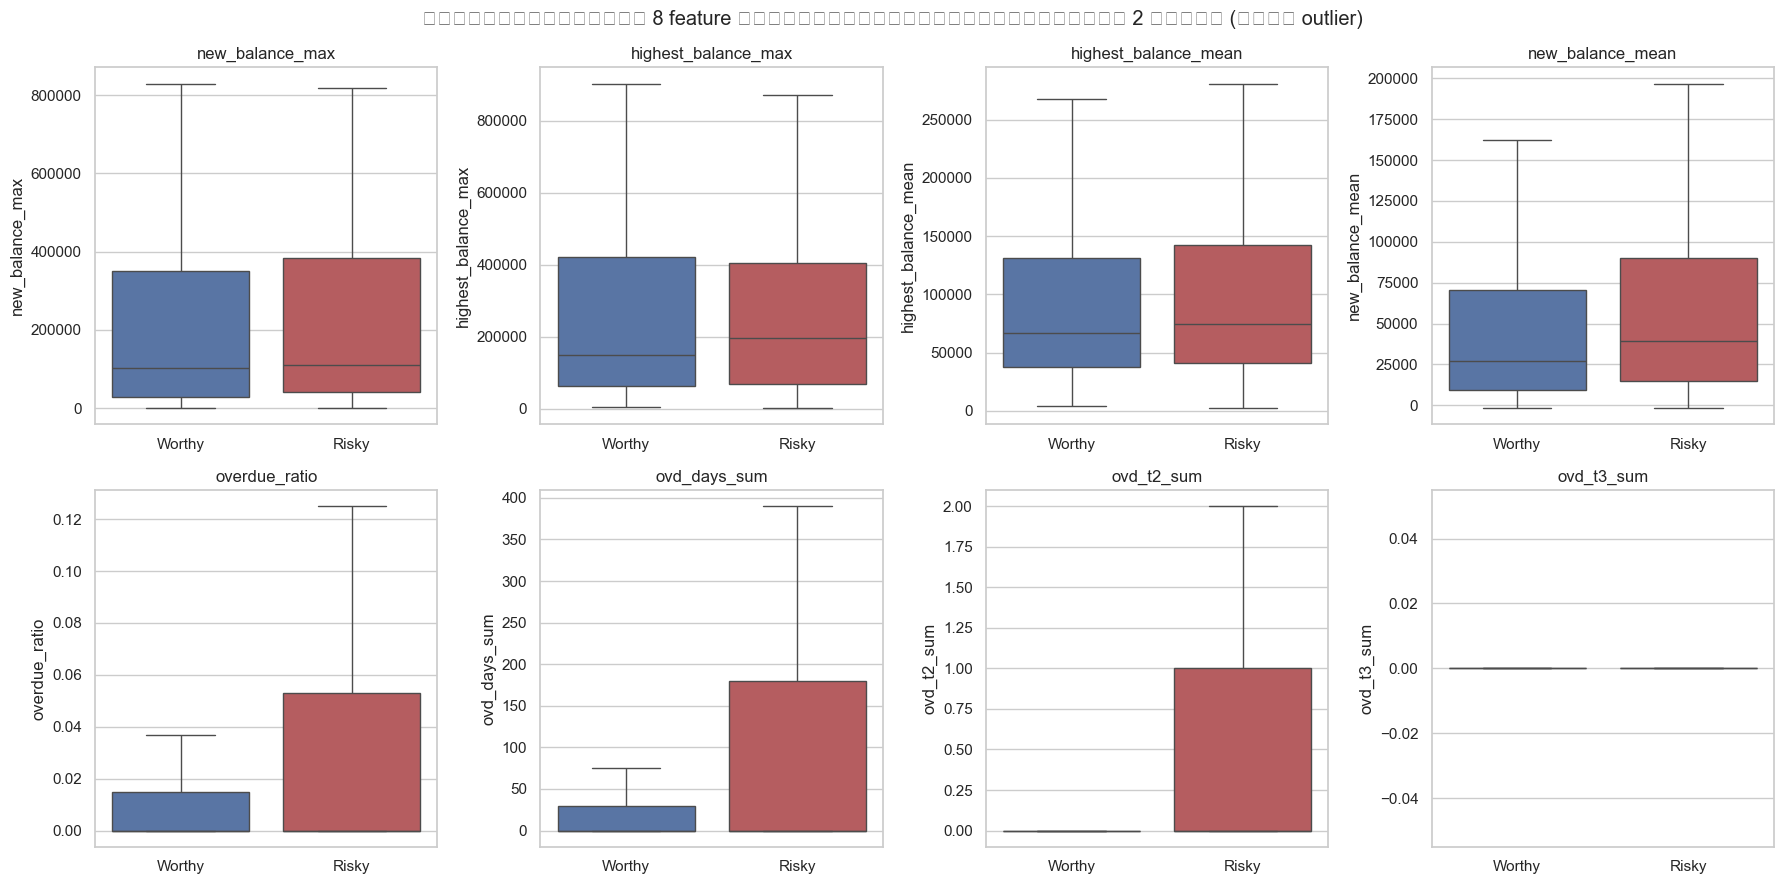

In [9]:
top_features = group_means.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flatten(), top_features):
    sns.boxplot(data=df, x="label", y=col, ax=ax, palette=["#4C72B0", "#C44E52"], showfliers=False)
    ax.set_xticklabels(["Worthy", "Risky"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("การกระจายตัวของ 8 feature ที่ต่างกันมากที่สุดระหว่าง 2 กลุ่ม (ซ่อน outlier)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_top_features_boxplots.png", dpi=150)
plt.show()

**จุดประสงค์ของกราฟนี้**: แสดง 'การกระจายตัว' จริงของแต่ละ feature ไม่ใช่แค่ค่าเฉลี่ย เหมือนตารางก่อนหน้า — ถ้ากล่อง (box) ของ 2 กลุ่มแยกออกจากกันชัดเจน (ไม่ทับซ้อนกันมาก) แปลว่า feature นั้นแยกแยะ 2 กลุ่มได้ดี แต่ถ้ากล่องทับซ้อนกันเยอะ แปลว่าแยกแยะได้ไม่ชัดนัก แม้ค่าเฉลี่ยจะต่างกันตามตารางก็ตาม

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/3425548828.py:7: UserW

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/ana

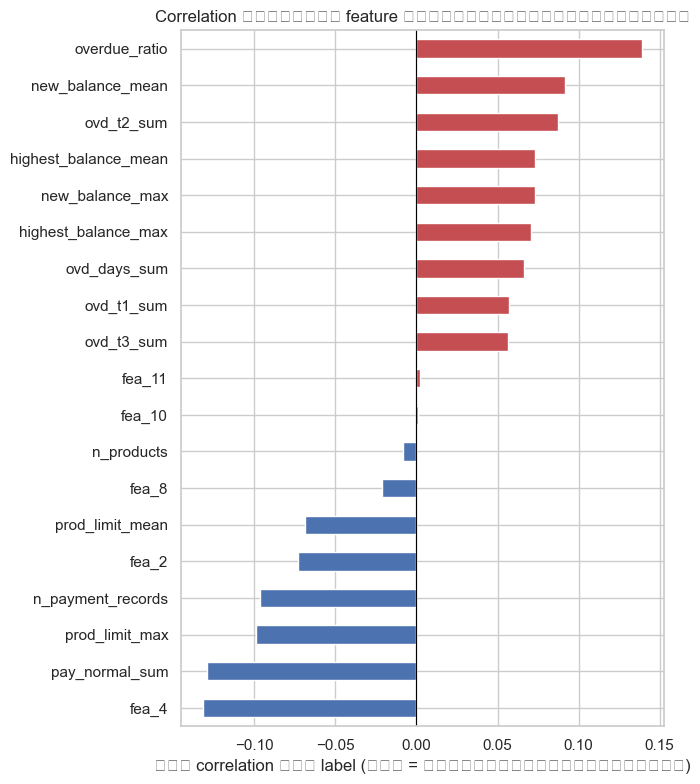

In [10]:
corr_with_label = df[numeric_cols + ["label"]].corr()["label"].drop("label").sort_values()
plt.figure(figsize=(7, 8))
corr_with_label.plot(kind="barh", color=corr_with_label.apply(lambda v: "#C44E52" if v > 0 else "#4C72B0"))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("ค่า correlation กับ label (บวก = สัมพันธ์กับความเสี่ยง)")
plt.title("Correlation ของแต่ละ feature กับความเสี่ยงด้านเครดิต")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_correlation_with_label.png", dpi=150)
plt.show()

**จุดประสงค์ของกราฟนี้**: จัดอันดับทุก feature พร้อมทิศทางไว้ในภาพเดียว — แท่งสีแดงยื่นไปทางขวา (บวก) หมายถึง feature นั้นสัมพันธ์กับความเสี่ยง ส่วนแท่งสีน้ำเงินยื่นไปทางซ้าย (ลบ) หมายถึงสัมพันธ์กับความน่าเชื่อถือ ยิ่งแท่งยาวยิ่งสัมพันธ์แรง ใช้เป็นจุดเช็คว่าไปทางเดียวกับ ตาราง group_means ก่อนหน้าหรือไม่

## ขั้นที่ 5: เตรียมข้อมูล + สร้างโมเดล (Preprocessing & Modeling)

EDA บอก "ความสัมพันธ์ดิบๆ" แต่มี 2 เรื่องที่ทำให้ EDA เพียงอย่างเดียวเชื่อถือไม่ได้ 100%:
- feature หนึ่งอาจดู "สำคัญ" เพราะมันสัมพันธ์กับ feature อื่นที่สำคัญจริงๆ (ไม่ได้สำคัญด้วยตัวมันเอง)
- ค่าผิดปกติ (outlier) อาจทำให้ค่าเฉลี่ยเบี้ยวไป

**โมเดล** ช่วยแก้ปัญหานี้ เพราะให้ทุก feature "แข่งกัน" พร้อมกันทั้งหมด เป็นวิธีจัดอันดับที่น่าเชื่อถือกว่า

### เตรียมข้อมูลก่อนเข้าโมเดล (Preprocessing)

1. **One-Hot Encoding** — `fea_1, fea_3, ...` เป็นรหัสตัวเลขที่ไม่มีลำดับความหมาย (รหัส 3 ไม่ได้ "มากกว่า" รหัส 1) ถ้าปล่อยให้โมเดลอ่านเป็นตัวเลขตรงๆ จะเข้าใจผิดว่ามีลำดับ จึงต้องแปลงเป็นคอลัมน์ 0/1 แยกสำหรับแต่ละหมวดหมู่แทน
2. **Train/Test Split แบบ Stratified** — แบ่งข้อมูล 75% เทรน / 25% ทดสอบ โดยใช้ `stratify=y` เพื่อรักษาสัดส่วน 80/20 ให้เท่ากันทั้ง 2 ฝั่ง (ไม่งั้นอาจสุ่มได้ test set ที่มีกลุ่มเสี่ยงน้อยผิดปกติ วัดผลไม่แม่น)
3. **Feature Scaling** — ใช้เฉพาะกับ Logistic Regression: ปรับทุก feature ให้อยู่ในสเกลเดียวกัน (mean=0, std=1) ไม่งั้น feature ที่ตัวเลขใหญ่ (เช่น ยอดเงินหลักแสน) จะดู "สำคัญ" กว่าที่ควรจะเป็นเมื่อเทียบ coefficient กับ feature สเกลเล็ก
4. **Class Weight Balancing** — ใช้ `class_weight="balanced"` เพื่อบังคับให้โมเดลสนใจกลุ่มเสี่ยง (ส่วนน้อย) มากขึ้น แก้ปัญหาข้อมูลไม่สมดุลที่เจอในขั้นที่ 2

In [11]:
model_df = pd.get_dummies(df.drop(columns=["id"]), columns=categorical_cols, drop_first=True)
X = model_df.drop(columns=["label"])
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (843, 49)  Test: (282, 49)


### โมเดลที่ 1: Logistic Regression

**หลักการทำงาน**:
1. รวม feature ทุกตัวถ่วงน้ำหนัก (w) บวกกันเป็นค่า `z` คล้ายสมการเส้นตรง: `z = w1*x1 + w2*x2 + ... + bias`
2. ค่า `z` มีค่าได้ตั้งแต่ -∞ ถึง +∞ แต่เราอยากได้ "ความน่าจะเป็น" ที่อยู่ระหว่าง 0-1 จึงบีบด้วย **sigmoid function**: `probability = 1 / (1 + e^-z)` (กราฟหน้าตาเป็นตัว S)
3. ถ้า probability ≥ 0.5 → ทำนายว่า "เสี่ยง"
4. ตอนเทรน โมเดลจะปรับน้ำหนัก (w) ไปเรื่อยๆ ด้วยวิธี **gradient descent** เพื่อให้ทำนายใกล้เคียงคำตอบจริงมากที่สุด

**จุดเด่น**: ตีความง่าย — ดูเครื่องหมาย (+/-) ของ coefficient แต่ละตัวได้ทันทีว่า feature นั้นเพิ่มหรือลดความเสี่ยง

In [12]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("เทรน Logistic Regression เสร็จแล้ว")

เทรน Logistic Regression เสร็จแล้ว


### โมเดลที่ 2: Random Forest

**หลักการทำงาน**: เป็น **ensemble model** (โมเดลรวมหมู่) สร้าง decision tree (ต้นไม้ตัดสินใจ) จำนวนมาก (300 ต้น) โดยแต่ละต้นเห็นข้อมูล/feature คนละชุดแบบสุ่ม (เทคนิคเรียกว่า **Bagging**) แล้วให้แต่ละต้น "โหวต" คำตอบ เอาเสียงส่วนใหญ่เป็นคำตอบสุดท้าย

จำกัดความลึกของต้นไม้ (`max_depth=6`) เพื่อไม่ให้แต่ละต้นซับซ้อนเกินจนจำข้อมูล train ได้หมด (overfitting) — เหมือนบังคับให้แต่ละต้นตัดสินใจแบบหยาบๆ แล้วอาศัยจำนวนต้นเยอะๆ ช่วยกันตัดสินให้แม่นขึ้นแทน

**จุดเด่น**: จับความสัมพันธ์ที่ไม่เป็นเส้นตรงได้ดีกว่า และให้ค่า **feature importance** (ความสำคัญของแต่ละ feature) มาโดยอัตโนมัติ

In [13]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6, class_weight="balanced", random_state=42
)
rf.fit(X_train, y_train)
print("เทรน Random Forest เสร็จแล้ว")

เทรน Random Forest เสร็จแล้ว


## ขั้นที่ 6: วัดผลโมเดล (Evaluation)

ตัวชี้วัดที่ใช้ และความหมายของแต่ละตัว:

- **Accuracy** — สัดส่วนที่ทำนายถูกทั้งหมด *ระวัง*: ข้อมูลไม่สมดุล (80/20) ทำให้ accuracy สูงได้ง่ายๆ แค่ทายกลุ่มใหญ่ตลอด จึงไม่ใช่ตัวชี้วัดที่น่าเชื่อถือที่สุดสำหรับข้อมูลแบบนี้
- **ROC-AUC** — วัดว่าโมเดล "แยกแยะ" 2 กลุ่มได้ดีแค่ไหน โดยไม่ขึ้นกับ threshold ตายตัว ค่า 1.0 = แยกได้สมบูรณ์แบบ, 0.5 = เดาสุ่ม เหมาะกับข้อมูลไม่สมดุลมากกว่า accuracy
- **Confusion Matrix** — ตารางเทียบคำตอบจริงกับคำตอบที่ทำนาย ช่วยเห็นว่าโมเดลพลาดแบบไหนบ่อยกว่ากัน
- **Precision / Recall / F1** — โฟกัสกลุ่มเสี่ยงโดยเฉพาะ: Precision = ทายว่าเสี่ยง ถูกจริงกี่ %, Recall = ในกลุ่มเสี่ยงจริงทั้งหมด จับได้กี่ % ในบริบทธนาคาร **Recall ของกลุ่มเสี่ยงมักสำคัญกว่า** เพราะปล่อยลูกค้าเสี่ยงหลุดไป (false negative) มักเสียหายมากกว่าระแวงลูกค้าดีเกินจำเป็น (false positive)

In [14]:
def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    print(f"\n--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_te, pred), 3))
    print("ROC-AUC :", round(roc_auc_score(y_te, proba), 3))
    print("Confusion matrix [[TN, FP], [FN, TP]]:\n", confusion_matrix(y_te, pred))
    print(classification_report(y_te, pred, target_names=["Worthy", "Risky"]))

evaluate("Logistic Regression", log_reg, X_test_scaled, y_test)
evaluate("Random Forest", rf, X_test, y_test)


--- Logistic Regression ---
Accuracy: 0.599
ROC-AUC : 0.676
Confusion matrix [[TN, FP], [FN, TP]]:
 [[133  93]
 [ 20  36]]
              precision    recall  f1-score   support

      Worthy       0.87      0.59      0.70       226
       Risky       0.28      0.64      0.39        56

    accuracy                           0.60       282
   macro avg       0.57      0.62      0.55       282
weighted avg       0.75      0.60      0.64       282


--- Random Forest ---
Accuracy: 0.734
ROC-AUC : 0.681
Confusion matrix [[TN, FP], [FN, TP]]:
 [[185  41]
 [ 34  22]]
              precision    recall  f1-score   support

      Worthy       0.84      0.82      0.83       226
       Risky       0.35      0.39      0.37        56

    accuracy                           0.73       282
   macro avg       0.60      0.61      0.60       282
weighted avg       0.75      0.73      0.74       282



**อ่านผลอย่างไร**: ถ้า ROC-AUC อยู่ราวๆ 0.65-0.75 แปลว่าโมเดลพอแยกแยะกลุ่มเสี่ยง/ไม่เสี่ยงได้ในระดับหนึ่ง (ดีกว่าเดาสุ่มชัดเจน) แต่ยังไม่ใช่โมเดลที่แม่นยำสมบูรณ์แบบ — เหมาะสมกับข้อมูลขนาดเล็กและไม่สมดุลแบบชุดนี้ ควรใช้ผลลัพธ์เป็นแนวทางประกอบการตัดสินใจ ไม่ใช่คำตอบเด็ดขาด

## ขั้นที่ 7: จัดอันดับปัจจัย (Feature Ranking)

รวมหลักฐานจาก **3 แหล่งที่เป็นอิสระต่อกัน** เพื่อความน่าเชื่อถือ (เรียกว่า triangulation):

1. **Logistic Regression coefficient** — บอกทิศทาง + ความแรงเชิงเส้น
2. **Random Forest feature importance** — บอกความสำคัญโดยรวม (ไม่บอกทิศทาง)
3. **% ส่วนต่างจาก EDA** (ขั้นที่ 3) — ค่าเฉลี่ยจริงต่างกันแค่ไหนระหว่าง 2 กลุ่ม

ถ้าทั้ง 3 แหล่งชี้ไปทางเดียวกัน ถือว่าเป็นสัญญาณที่น่าเชื่อถือมาก เพราะไม่ได้พึ่งพาวิธีวัดแบบเดียว

In [15]:
coef_series = pd.Series(log_reg.coef_[0], index=X.columns, name="logreg_coef")
importance_series = pd.Series(rf.feature_importances_, index=X.columns, name="rf_importance")

factor_table = pd.concat([coef_series, importance_series], axis=1)
factor_table["rf_importance_rank"] = factor_table["rf_importance"].rank(ascending=False)
factor_table = factor_table.sort_values("rf_importance", ascending=False)

factor_table.to_csv(f"{OUTPUT_DIR}/feature_importance_summary.csv")
factor_table.head(10).round(4)

,logreg_coef,rf_importance,rf_importance_rank
fea_4,-0.6322,0.1342,1.0
pay_normal_sum,-0.2485,0.0897,2.0
prod_limit_max,-0.1135,0.0783,3.0
new_balance_mean,0.0227,0.0669,4.0
highest_balance_mean,0.3977,0.0587,5.0
highest_balance_max,0.7557,0.0566,6.0
new_balance_max,0.2754,0.0558,7.0
prod_limit_mean,0.1313,0.0554,8.0
fea_2,-0.0474,0.0432,9.0
n_payment_records,-0.5273,0.0392,10.0


**จุดประสงค์ของตารางนี้**: เป็นผลลัพธ์จาก 'โมเดล' ไม่ใช่แค่ EDA ดิบๆ อีกต่อไป — `logreg_coef` บอกทิศทาง (บวก/ลบ) ส่วน `rf_importance` บอกอันดับความสำคัญโดยรวม เรียงจากสำคัญที่สุดไปน้อยที่สุด ใช้เทียบกับตาราง group_means ในขั้นที่ 3 ว่าปัจจัยเดิม ยังคงสำคัญอยู่ไหม หลังให้ทุก feature 'แข่งกัน' พร้อมกันในโมเดลจริง

/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_224/956072149.py:6: UserWarni

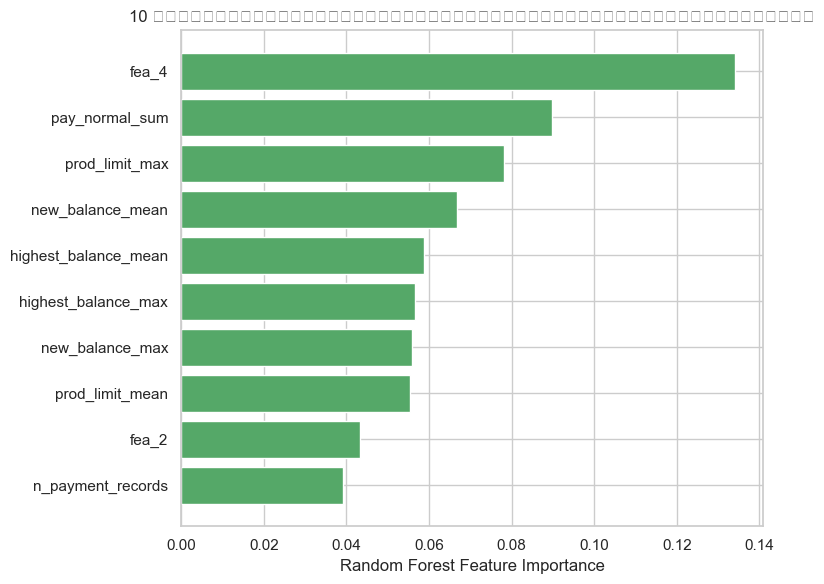

In [16]:
plt.figure(figsize=(8, 6))
top10 = factor_table.head(10).sort_values("rf_importance")
plt.barh(top10.index, top10["rf_importance"], color="#55A868")
plt.xlabel("Random Forest Feature Importance")
plt.title("10 ปัจจัยที่มีผลต่อการทำนายความเสี่ยงด้านเครดิตมากที่สุด")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_top_factors_importance.png", dpi=150)
plt.show()

**จุดประสงค์ของกราฟนี้**: สรุปภาพรวม 10 อันดับปัจจัยที่ Random Forest ให้น้ำหนักมากที่สุด เหมาะสำหรับสื่อสารกับคนที่ไม่ได้อ่านตัวเลขในตาราง — แท่งยิ่งยาว ยิ่งเป็นปัจจัยที่โมเดลใช้ตัดสินใจ บ่อยและมีผลต่อการทำนายมาก

## ขั้นที่ 8: สรุปคำตอบ Q1 และ Q2 (Interpretation)

ขั้นตอนสุดท้าย: แปลงตัวเลขทั้งหมดจากขั้นก่อนหน้าให้เป็นคำตอบภาษาคนที่อ่านรู้เรื่อง โดยดึงปัจจัยอันดับต้นๆ จากตาราง `factor_table` แล้วเทียบทิศทาง (สูง/ต่ำ) จากค่าเฉลี่ยจริงในขั้นที่ 3 มาประกอบเป็นประโยคสรุป — ไม่ได้เขียนคำตอบไว้ล่วงหน้า แต่ให้โค้ดสร้างขึ้นจากตัวเลขจริงที่คำนวณได้

In [17]:
def direction_word(feature, factor_row, group_row):
    coef = factor_row.get("logreg_coef", 0)
    if feature in group_row.index:
        pct = group_row.loc[feature, "pct_diff_%"]
        if pd.notna(pct):
            return "สูงกว่า" if pct > 0 else "ต่ำกว่า"
    return "สูงกว่า" if coef > 0 else "ต่ำกว่า"


top_risk_factors = factor_table.head(6)
print("=" * 70)
print("คำตอบ Q1: อะไรทำให้ลูกค้าเป็น Credit Risky?")
print("=" * 70)
for feat in top_risk_factors.index:
    if feat not in group_means.index:
        continue
    direction = direction_word(feat, top_risk_factors.loc[feat], group_means)
    pct = group_means.loc[feat, "pct_diff_%"]
    print(f"- {feat}: กลุ่มเสี่ยงมีค่า{direction}กลุ่มไม่เสี่ยง (เฉลี่ยต่าง {pct:+.1f}%)")

print(
    "\nสรุป: ลูกค้ากลุ่มเสี่ยงแยกออกจากกลุ่มไม่เสี่ยงได้ชัดเจนที่สุดจาก 'พฤติกรรมการใช้เงิน "
    "และการชำระเงิน' ไม่ใช่ข้อมูลประชากรศาสตร์ — มียอดหนี้/ยอดคงเหลือสูงกว่า, ค้างจ่ายบ่อยกว่า, "
    "และจ่ายตรงเวลาน้อยกว่ากลุ่มไม่เสี่ยงอย่างชัดเจน"
)

คำตอบ Q1: อะไรทำให้ลูกค้าเป็น Credit Risky?
- fea_4: กลุ่มเสี่ยงมีค่าต่ำกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง -22.9%)
- pay_normal_sum: กลุ่มเสี่ยงมีค่าต่ำกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง -30.0%)
- prod_limit_max: กลุ่มเสี่ยงมีค่าต่ำกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง -17.1%)
- new_balance_mean: กลุ่มเสี่ยงมีค่าสูงกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง +139.9%)
- highest_balance_mean: กลุ่มเสี่ยงมีค่าสูงกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง +174.5%)
- highest_balance_max: กลุ่มเสี่ยงมีค่าสูงกว่ากลุ่มไม่เสี่ยง (เฉลี่ยต่าง +207.5%)

สรุป: ลูกค้ากลุ่มเสี่ยงแยกออกจากกลุ่มไม่เสี่ยงได้ชัดเจนที่สุดจาก 'พฤติกรรมการใช้เงิน และการชำระเงิน' ไม่ใช่ข้อมูลประชากรศาสตร์ — มียอดหนี้/ยอดคงเหลือสูงกว่า, ค้างจ่ายบ่อยกว่า, และจ่ายตรงเวลาน้อยกว่ากลุ่มไม่เสี่ยงอย่างชัดเจน


In [18]:
print("=" * 70)
print("คำตอบ Q2: ลูกค้า Credit Worthy มีพฤติกรรมอย่างไร?")
print("=" * 70)
worthy_profile = group_means.loc[[f for f in top_risk_factors.index if f in group_means.index]]
print(worthy_profile[["worthy_mean (label=0)"]].round(2))

print(
    "\nสรุป: ลูกค้ากลุ่มน่าเชื่อถือคุมยอดคงเหลือให้อยู่ในระดับต่ำ, แทบไม่ค้างชำระ "
    f"(overdue_ratio เฉลี่ยราว {group_means.loc['overdue_ratio', 'worthy_mean (label=0)']:.1%}), "
    f"และจ่ายเงินตรงเวลาอย่างสม่ำเสมอ (เฉลี่ย {group_means.loc['pay_normal_sum', 'worthy_mean (label=0)']:.0f} "
    "ครั้งของการจ่ายปกติ) — ความสม่ำเสมอในการจ่ายเงินตรงเวลาและการควบคุมยอดหนี้ คือสัญญาณหลักของลูกค้าน่าเชื่อถือ"
)

คำตอบ Q2: ลูกค้า Credit Worthy มีพฤติกรรมอย่างไร?
                      worthy_mean (label=0)
fea_4                             126694.44
pay_normal_sum                       113.32
prod_limit_max                    112615.49
new_balance_mean                   71114.69
highest_balance_mean              124362.20
highest_balance_max               469921.60

สรุป: ลูกค้ากลุ่มน่าเชื่อถือคุมยอดคงเหลือให้อยู่ในระดับต่ำ, แทบไม่ค้างชำระ (overdue_ratio เฉลี่ยราว 3.1%), และจ่ายเงินตรงเวลาอย่างสม่ำเสมอ (เฉลี่ย 113 ครั้งของการจ่ายปกติ) — ความสม่ำเสมอในการจ่ายเงินตรงเวลาและการควบคุมยอดหนี้ คือสัญญาณหลักของลูกค้าน่าเชื่อถือ


## ข้อควรระวังในการอ่านผลลัพธ์

- โมเดลมี ROC-AUC ประมาณ 0.65-0.75 (ไม่ใช่ 1.0) แปลว่าพอแยกแยะได้ในระดับหนึ่ง แต่ยังไม่แม่นยำสมบูรณ์ เนื่องจากข้อมูลมีขนาดเล็ก (1,125 คน) และไม่สมดุล (มีกลุ่มเสี่ยงเพียง 20%)
- ผลลัพธ์นี้บอกความ **"สัมพันธ์" (correlation)** ไม่ใช่ **"สาเหตุ" (causation)** — เช่น ยอดหนี้สูงอาจเป็นทั้งสาเหตุและผลลัพธ์ของความเสี่ยงพร้อมกันได้ ควรใช้เป็นแนวทางประกอบการตัดสินใจ ไม่ใช่ข้อสรุปเด็ดขาด

---

*ดูเวอร์ชัน script (`.py`) ล้วนได้ที่ [`analysis.py`](analysis.py) และรายละเอียดเชิงเทคนิคเพิ่มเติมได้ที่ [`METHODOLOGY.md`](METHODOLOGY.md)*